**Required viewing**

[Clustering MIT](https://www.youtube.com/watch?v=dyb_cFywuik)

**Clustering**
- Machine learning technique that uses unsupervised learning
- Group unlabelled data into natural clusters
- Clustering is an optimisation problem
- $variability(c) = \sum_{e \in c}distance(mean(c), e)^2$
- Variance is different from variability, you don't divide by n.This is because in clustering big and bad is worse than small and bad. We don't want to average out the difference.
- $dissimilarity(C) = \sum_{c \in C}variability(c)$
- Find C that minimises the dissimilarity
- In order for this not to end up as each point being a cluster, we add a constraint e.g the clusters have to have some minimum distance or contrain the number of clusters


**Hierarchical clustering**
- Start by assigning each item to a cluster so that you have $N$ items, you know have $N$ clusters, each containing one item
- Find the closest (most similar) pair of clusters and merge them inti a single cluster, so now we have one fewer clusters
- Continue until all items are clustered into a single cluster of size $N$ 
- Agglomerative hierarchical cluster
- What do we mean by closest?
- Can get clusters depending on the linkage metric
- **Single linkage**: consider between the distance between one cluster and another to be equal to the shortest distance of any member of one cluster to any member of another cluster
- **Complete Linkage**: consider the distance between one cluster and another cluster as the greatest distance from any member of one cluster to any member of another cluster
- **Average Linkage**: consider the distance between one cluster and another cluster as the average distance from any member of one cluster to any member of the other cluster

|BOS|NY|CHI|DEN|SF|SEA|
|---|---|---|---|---|---|
|0|206|963|1949|3095|2979|
|0|0|802|1771|2934|2815|
|0|0|0|966|1235|1307|
|0|0|0|0|1235|1307|
|0|0|0|0|0|808|
|0|0|0|0|0|0|

**Clusters**
- [BOS, NY] [CHI] [DEN] [SF] [SEA]
- **Single** [BOS, NY, CHI] [DEN] [SF] [SEA]
- **Complete** [BOS, NY] [CHI] [DEN] [SF, SEA]
- **Single** [BOS, NY, CHI] [DEN] [SF, SEA]
- **Complete** [BOS, NY, CHI] [DEN] [SF, SEA]
- **Single** [BOS, NY, CHI, DEN] [SF, SEA]
- **Complete** [BOS, NY, CHI] [DEN, SF, SEA]

**Pros and cons of hierarchical clustering**
- Get history of dendrograms
- Deterministic given a linkage metric
- Answer might not be optimal. Greedy algorithm. Making locally optimal decisions at each point that might not lead to globally optimal solution
- Flexible
- Really slow. Complexity $O(n^3)$. Not something to use with large data sets


In [2]:
import numpy as np
import matplotlib.pyplot as plt 
import scipy.cluster.hierarchy as sch

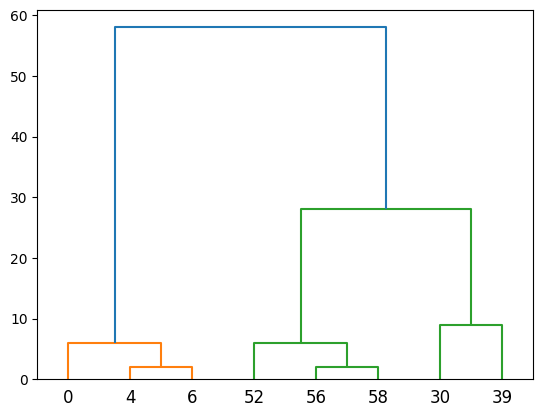

In [4]:
data = [0, 4, 6, 30, 39, 52, 56, 58]
Z = np.reshape(data, (len(data), 1))
dendrogram = sch.dendrogram(sch.linkage(Z, method='complete'), labels = data)

In [5]:
airports = ['BOS', 'NY', 'CHI', 'DEN', 'SF', 'SEA']
distance = [[0, 206, 963, 1949, 3095, 2979], 
            [206, 0, 802, 1771, 2934, 2815],
            [963, 802, 0, 966, 2142, 2013],
            [1949, 1771, 966, 0, 1235, 1307],
            [3095, 2934, 2142, 1235, 0, 808],
            [2979, 2815, 2013, 1307, 808,0]]

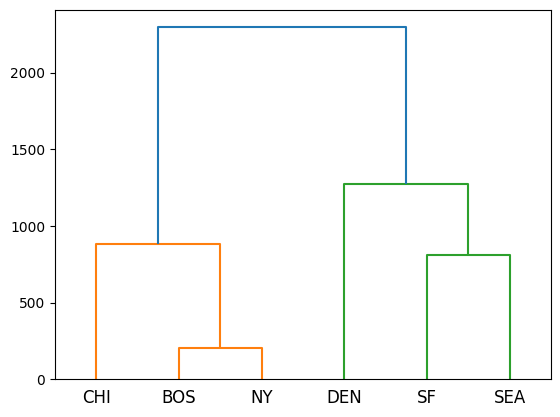

In [8]:
from scipy.spatial.distance import squareform
condensed_dist_matrix = squareform(distance)
dendrogram = sch.dendrogram(sch.linkage(condensed_dist_matrix, method='average'), labels = airports)

**k-means clustering**
- k is the number of clusters that you want
- If you don't have any idea about how many clusters there are this can be problematic
- If you know how many clusters there are this is a good choice as it is very fast


**k-means algorithm**
- Randomly choice samples as initial centroid
- while True:
- create k clusters by assigning each point to the closest cluster
- computer k new centroids by averaging the examples in each cluster
- if the centroids don't change exit

- Complexity of one iteration
- Compare each point with each centroid k*n
- Typically this converges quite quickly
- Most commonly used clustering algorithm as it is very fast

**Choosing k**
- Choosing wrong k can be problematic
- If k is non-sensical then your clustering will be non-sensical
- How do we choose k?
- Results can depend on the initial centroids
- k-means is non-deterministic
- If the initials centroids are poorly can take longer to converge or we can get a completely different answer